# Experiment 2: Polynomial Regression on Auto MPG Dataset
## Aim
Predict MPG using engine displacement and compare Linear and Polynomial Regression.

## Theory
Polynomial Regression models nonlinear relationships by adding higher-order terms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

/home/student/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df=sns.load_dataset('mpg')
df=df[['mpg','displacement']].dropna()
df.head()

,mpg,displacement
0,18.0,307.0
1,15.0,350.0
2,18.0,318.0
3,16.0,304.0
4,17.0,302.0


In [3]:
print(df.shape)
df.info()
df.describe()

(398, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   displacement  398 non-null    float64
dtypes: float64(2)
memory usage: 6.3 KB


,mpg,displacement
count,398.000000,398.000000
mean,23.514573,193.425879
std,7.815984,104.269838
min,9.000000,68.000000
25%,17.500000,104.250000
50%,23.000000,148.500000
75%,29.000000,262.000000
max,46.600000,455.000000


In [4]:
X=df[['displacement']]
y=df['mpg']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Linear Regression

In [5]:
linear=LinearRegression()
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)
print('MSE',mean_squared_error(y_test,y_pred))
print('R2',r2_score(y_test,y_pred))

MSE 18.102543998358946
R2 0.6633114869465596


## Polynomial Regression (Degrees 2, 3 and 4)

In [6]:
for d in [2,3,4]:
    model=make_pipeline(PolynomialFeatures(d),LinearRegression())
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    print(d, mean_squared_error(y_test,pred), r2_score(y_test,pred))

2 15.10735356108076 0.7190189176110284
3 14.943631793037289 0.722063972418907
4 14.961486893912738 0.7217318860908903


/home/student/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/student/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/student/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/student/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


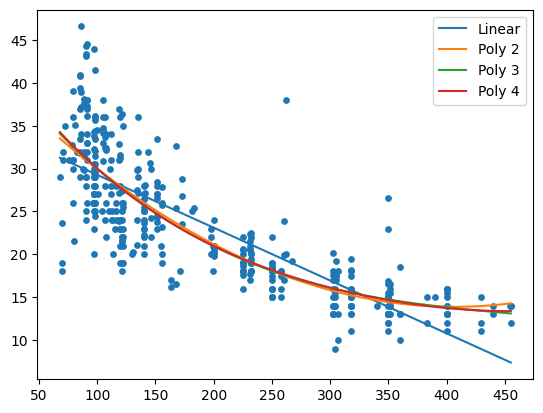

In [7]:
x=np.linspace(X.min().values[0],X.max().values[0],300).reshape(-1,1)
plt.scatter(X,y,s=15)
plt.plot(x,linear.predict(x),label='Linear')
for d in [2,3,4]:
    m=make_pipeline(PolynomialFeatures(d),LinearRegression())
    m.fit(X,y)
    plt.plot(x,m.predict(x),label=f'Poly {d}')
plt.legend()
plt.show()

## Conclusion
Compare the MSE and R² values. Lower MSE and higher R² indicate a better model.